In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from bev_generation.unet import Unet_BEVGenerator

model = Unet_BEVGenerator()


In [4]:
from expert_dataset_def.expert_dataset import ExpertDataset
import torch as th


dataloader = th.utils.data.DataLoader(
        dataset = ExpertDataset(
        dataset_directory="expert-data",
        unet=True),
        batch_size=4,
        shuffle=True,
    )

In [5]:

for i,expert_batch in enumerate(dataloader):
    expert_obs_dict, expert_action = expert_batch
    bev = model.infer(expert_obs_dict)
    if i == 0:
        break

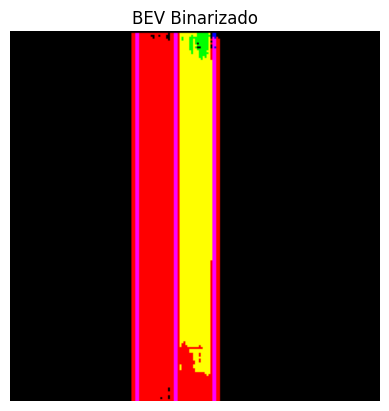

In [58]:
import matplotlib.pyplot as plt

bev_img = bev[3].detach().cpu()

# binariza
bev_bin = (bev_img > 0.5).float()

# plot
import matplotlib.pyplot as plt

bev_plot = bev_bin.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()

In [7]:
bev_bin = (bev > 0.5)

### Teste evaluation

In [ ]:
import numpy as np
import torch
import cv2
from PIL import Image
from expert_dataset_def.expert_dataset import traj_plotter, traj_plotter_rgb
import pandas as pd
import os

def create_image_tensor(obs, unet=False, w_resize=192, h_resize=192):
    """
    Prepara tensor de entrada para a UNet.
    Gera o traj_plot internamente a partir das coordenadas brutas em obs['traj'].
    """
    def process_image(image: np.ndarray, traj=False):
        # Garante que estamos trabalhando com numpy array
        if isinstance(image, torch.Tensor):
            image = image.cpu().numpy()
        
        if image.ndim == 4:
            image = image[0]  # Remove batch dim se existir

        if not traj:
            # Imagens das câmeras vêm como (H, W, 3) do PIL/numpy
            # Redimensiona primeiro mantendo formato HWC
            image = cv2.resize(image, (w_resize, h_resize),interpolation=cv2.INTER_NEAREST)  # (H, W, 3)
            # Converte para CHW para o tensor PyTorch
            image = image.transpose(2, 0, 1)  # (3, H, W)
        else:
            # traj_plot: pode vir como (H, W) ou (1, H, W)
            if image.ndim == 3 and image.shape[0] == 1:
                image = image[0]  # Remove channel dim extra se existir
            image = cv2.resize(image, (w_resize, h_resize),interpolation=cv2.INTER_NEAREST)  # (H, W)
            image = image[None, :, :]  # (1, H, W)

        return torch.as_tensor(image, dtype=torch.float32) / 255.0

    image_tensor_list = []
    

    # GERAÇÃO DO TRAJ_PLOT DENTRO DA FUNÇÃO
    if unet:
        camera_order = ["central_rgb", "left_rgb", "right_rgb", "rear_rgb"]
        # traj_plotter retorna tensor (1, H, W) em [0, 255]
        traj_tensor = traj_plotter(obs['traj'], w_resize, h_resize)
        traj_plot = traj_tensor / 255.0  # Normaliza para [0, 1]
    else:
        camera_order = ["left_rgb", "central_rgb", "right_rgb", "rear_rgb"]
        # traj_plotter_rgb retorna tensor (3, H, W) em [0, 255]
        traj_tensor = traj_plotter_rgb(obs['traj'], w_resize, h_resize)
        traj_plot = traj_tensor / 255.0
    
    for i in camera_order:
        image_tensor_list.append(process_image(obs[i]))

    image_tensor_list.append(traj_plot)
    images = torch.cat(image_tensor_list, dim=0)  # Concatena ao longo dos canais: 4*3 + 1 = 13
    return images.unsqueeze(0)  # Adiciona batch dim: (1, 13, 192, 192)

def load_cam(path):
    return np.array(Image.open(path).convert('RGB'))

In [45]:
caminho_rota = "/home/felipe_cds/carla-bc-bev/expert-data/route_00/ep_00"
json_path = os.path.join(caminho_rota, 'episode.json')
frame_idx = 133
df = pd.read_json(json_path)
obs = {
    'left_rgb': load_cam(os.path.join(caminho_rota, 'left_rgb', f'{frame_idx:04d}.png')),
    'central_rgb': load_cam(os.path.join(caminho_rota, 'central_rgb', f'{frame_idx:04d}.png')),
    'right_rgb': load_cam(os.path.join(caminho_rota, 'right_rgb', f'{frame_idx:04d}.png')),
    'rear_rgb': load_cam(os.path.join(caminho_rota, 'rear_rgb', f'{frame_idx:04d}.png')),
    'traj': df['traj'].iloc[frame_idx],  # Passa coordenadas brutas
}
        
        # Prepara tensor para inferência e roda a UNet
inp_tensor = create_image_tensor(obs, unet=True).to("cuda")
        

In [46]:
bev_geneated = model.infer({'image': inp_tensor})

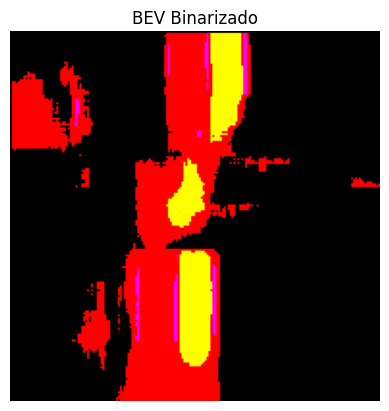

In [47]:
import matplotlib.pyplot as plt

bev_img = bev_geneated[0].detach().cpu()

# binariza
bev_bin = (bev_img > 0.5).float()


bev_plot = bev_bin.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()

## CVT

In [5]:
from bev_generation.cvt_3ch import CVT_3chL1Generator

model = CVT_3chL1Generator(device='cuda')

Loaded pretrained weights for efficientnet-b4


In [4]:
from expert_dataset_def.expert_dataset import ExpertDataset
import torch as th


dataloader = th.utils.data.DataLoader(
        dataset = ExpertDataset(
        dataset_directory="expert-data",
        unet=False),
        batch_size=4,
        shuffle=True,
    )

In [6]:

for i,expert_batch in enumerate(dataloader):
    expert_obs_dict, expert_action = expert_batch
    bev = model.infer(expert_obs_dict)
    if i == 0:
        break

In [11]:
bev.min()

tensor(-0.0211)

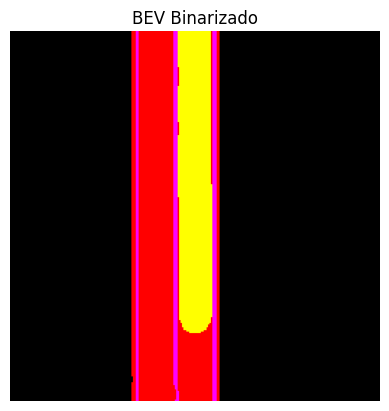

In [14]:
import matplotlib.pyplot as plt

bev_img = bev[3].detach().cpu()

# binariza
#bev_bin = (bev_img > 0.5).float()


bev_plot = bev_bin.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()